In [1]:
from earthkit.data.utils.testing import earthkit_remote_test_data_file

from earthkit import data as ekd
from earthkit import transforms as ekt
from earthkit import plots as ekp

import xarray
xarray.set_options(keep_attrs=True)

ekd.settings.set("cache-policy", "user")

In [2]:


# Get some demonstration ERA5 data, this could be any url or path to an ERA5 grib or netCDF file.
remote_seas5_file = earthkit_remote_test_data_file("seas5_2m_temperature_201501-201503_europe_1deg.grib")
seas5_data = ekd.from_source("url", remote_seas5_file)
seas5_xr = seas5_data.to_xarray(time_dim_mode="forecast", add_valid_time_coord=True).rename({"2t": "t2m"})
seas5_xr



<xarray.Dataset> Size: 182MB
Dimensions:                  (member: 25, forecast_reference_time: 3,
                              step: 239, latitude: 31, longitude: 41)
Coordinates:
  * member                   (member) <U2 200B '0' '1' '10' '11' ... '7' '8' '9'
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 24B 201...
  * step                     (step) timedelta64[ns] 2kB 0 days 06:00:00 ... 5...
  * latitude                 (latitude) float64 248B 70.0 69.0 ... 41.0 40.0
  * longitude                (longitude) float64 328B -10.0 -9.0 ... 29.0 30.0
    valid_time               (forecast_reference_time, step) datetime64[ns] 6kB ...
Data variables:
    t2m                      (member, forecast_reference_time, step, latitude, longitude) float64 182MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [3]:
seas_daily_mean_by_step = ekt.temporal.daily_mean(seas5_xr, time_dim="step")
# We recreate the valid_time coordinate as it was lost during the reduction over the related dimensions.
seas_daily_mean_by_step.coords["valid_time"] = (
    seas_daily_mean_by_step["forecast_reference_time"] + seas_daily_mean_by_step["step"]
)
print(seas_daily_mean_by_step.t2m)


<xarray.DataArray 't2m' (step: 60, member: 25, forecast_reference_time: 3,
                         latitude: 31, longitude: 41)> Size: 46MB
array([[[[[269.24721146, 269.7174263 , 270.26247025, ...,
           272.21486282, 271.75148392, 272.24159622],
          [271.08925247, 271.58412552, 272.187397  , ...,
           272.00246048, 271.51808548, 271.01173782],
          [272.76588821, 273.28065872, 273.90980911, ...,
           271.96913528, 271.77833939, 271.25258255],
          ...,
          [285.60072708, 282.16334915, 278.18349075, ...,
           271.82826614, 276.09474564, 277.27370071],
          [286.06483841, 282.57838821, 278.38734818, ...,
           272.74977493, 277.03871536, 274.83522415],
          [286.211689  , 282.61781693, 278.37965775, ...,
           275.15993118, 273.39039993, 271.16591263]],

         [[267.28131104, 267.74688721, 268.53118896, ...,
           264.081604  , 264.66790771, 265.78765869],
          [267.69415283, 268.18170166, 268.7177124 , ...,


In [4]:


seas5_daily_mean_by_vt = ekt.temporal.daily_mean(
    seas5_xr,
    time_dim="valid_time",  extra_reduce_dims=["member"]
)
seas5_daily_std_by_vt = ekt.temporal.daily_std(
    seas5_xr,
    time_dim="valid_time",  extra_reduce_dims=["member"]
)
seas5_daily_mean_by_vt



{'dim': ['stacked_forecast_reference_time_step', 'member']}
FrozenMappingWarningOnValuesAccess(FrozenMappingWarningOnValuesAccess({'member': 25, 'latitude': 31, 'longitude': 41, 'stacked_forecast_reference_time_step': 3}))
{'dim': ['stacked_forecast_reference_time_step', 'member']}
FrozenMappingWarningOnValuesAccess(FrozenMappingWarningOnValuesAccess({'member': 25, 'latitude': 31, 'longitude': 41, 'stacked_forecast_reference_time_step': 3}))


<xarray.Dataset> Size: 1MB
Dimensions:    (date: 119, latitude: 31, longitude: 41)
Coordinates:
  * date       (date) datetime64[ns] 952B 2015-01-01 2015-01-02 ... 2015-04-29
  * latitude   (latitude) float64 248B 70.0 69.0 68.0 67.0 ... 42.0 41.0 40.0
  * longitude  (longitude) float64 328B -10.0 -9.0 -8.0 -7.0 ... 28.0 29.0 30.0
Data variables:
    t2m        (date, latitude, longitude) float64 1MB 269.5 270.0 ... 283.5
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

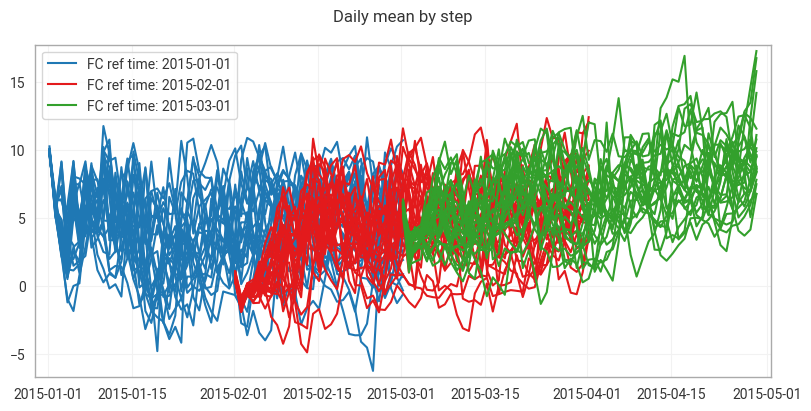

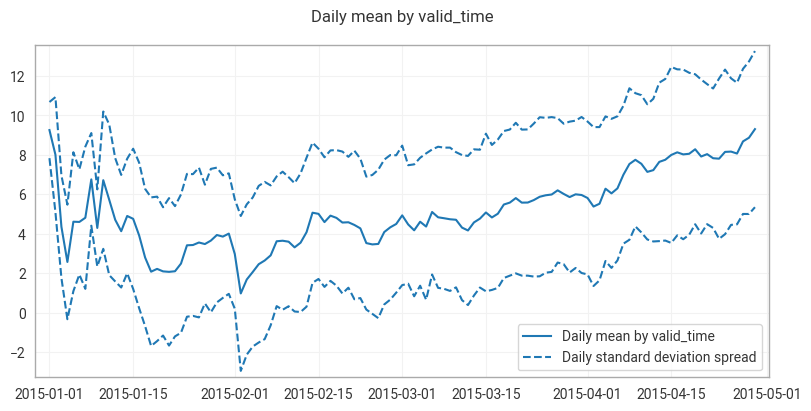

In [5]:


latitude = 52
longitude = -1.0
sel_kwargs = {"latitude": latitude, "longitude": longitude}
forecast_colours = ["#1f78b4", "#e31a1c", "#33a02c"]

# figure = ekp.Figure(rows=2, cols=1)
chart = ekp.TimeSeries()

for i, itime in enumerate(seas_daily_mean_by_step.forecast_reference_time.values):
    plt_colour = forecast_colours[i]
    for j, member in enumerate(seas_daily_mean_by_step.member.values):
        t_data = seas_daily_mean_by_step.t2m.sel(
            **sel_kwargs, member=member, forecast_reference_time=itime
        )
        if j == 0:
            extra_kwargs = {"label": f"FC ref time: {str(itime)[:10]}"}
        else:
            extra_kwargs = {}
        chart.line(t_data, x="valid_time", units="celsius", color=plt_colour, **extra_kwargs)
chart.title("Daily mean by step\n")
chart.legend()

chart2 = ekp.TimeSeries()
chart2.line(
    seas5_daily_mean_by_vt.t2m.sel(**sel_kwargs),
    x="date", units="celsius", label="Daily mean by valid_time",
    color="#1f78b4"
)
upper_m = seas5_daily_mean_by_vt + seas5_daily_std_by_vt
lower_m = seas5_daily_mean_by_vt - seas5_daily_std_by_vt
chart2.line(
    upper_m.sel(**sel_kwargs),
    x="date", units="celsius", label="Daily standard deviation spread",
    linestyle="--", color="#1f78b4"
)
chart2.line(
    lower_m.sel(**sel_kwargs),
    x="date", units="celsius", linestyle="--", color="#1f78b4"
)
chart2.title("Daily mean by valid_time\n")
chart2.legend()



In [6]:

latitude = 52
longitude = -1.0
sel_kwargs = {"latitude": latitude, "longitude": longitude}
upper_m = seas5_daily_mean_by_vt + seas5_daily_std_by_vt
lower_m = seas5_daily_mean_by_vt - seas5_daily_std_by_vt



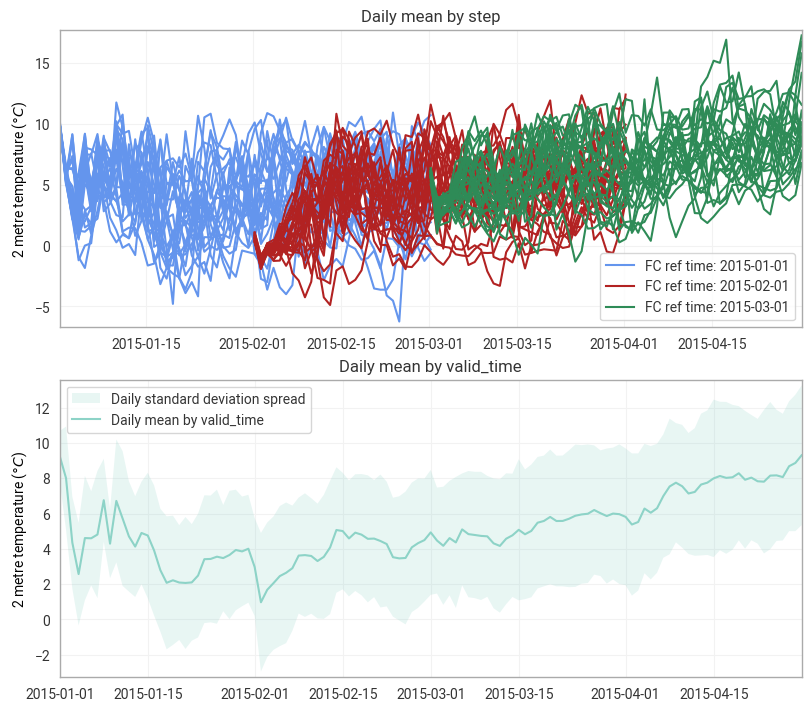

In [7]:
fig = ekp.Figure(rows=2, columns=1)

ts1 = fig.add_timeseries()
ts1.line(
    seas_daily_mean_by_step.t2m.sel(latitude=52, longitude=-1),
    x="valid_time",
    units="celsius",
    colorby="forecast_reference_time",
    colors=["cornflowerblue", "firebrick", "seagreen"],
    label="FC ref time: {forecast_reference_time:%Y-%m-%d}",
)
ts1.title("Daily mean by step")
ts1.legend()
ts1.ylabel()

ts2 = fig.add_timeseries()
ts2.fill_between(lower_m.sel(**sel_kwargs), upper_m.sel(**sel_kwargs), units="celsius", label="Daily standard deviation spread")
ts2.line(seas5_daily_mean_by_vt.sel(**sel_kwargs), units="celsius", label="Daily mean by valid_time")
ts2.title("Daily mean by valid_time")
ts2.legend()
ts2.ylabel()

fig.show()


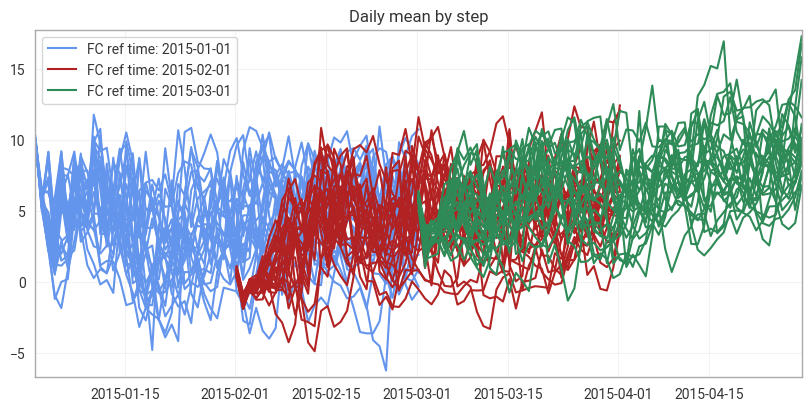

In [8]:
ts = ekp.TimeSeries()
ts.line(
    seas_daily_mean_by_step.t2m.sel(latitude=52, longitude=-1),
    x="valid_time",
    units="celsius",
    colorby="forecast_reference_time",
    colors=["cornflowerblue", "firebrick", "seagreen"],
    label="FC ref time: {forecast_reference_time:%Y-%m-%d}",
)
ts.title("Daily mean by step")
ts.legend()
ts.show()

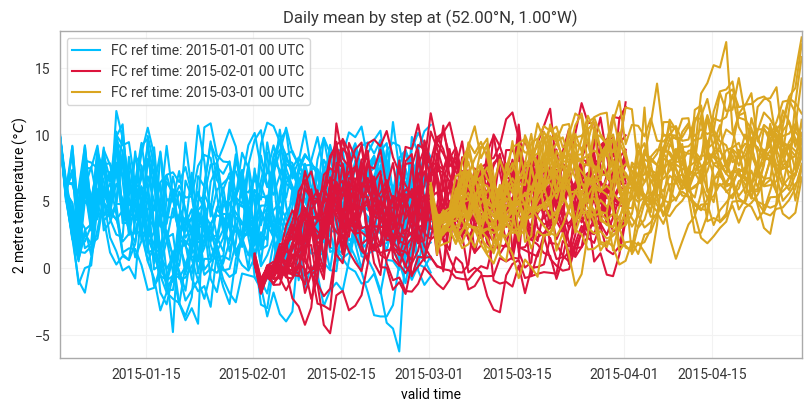

In [9]:
timeseries = ekp.timeseries.line(
    seas_daily_mean_by_step.t2m.sel(latitude=52, longitude=-1),
    x="valid_time",
    units="celsius",
    colorby="forecast_reference_time",
    colors=["deepskyblue", "crimson", "goldenrod"],
    label="FC ref time: {forecast_reference_time:%Y-%m-%d %H UTC}",
)
timeseries.legend()
timeseries.title("Daily mean by step at ({latitude:%Lt}, {longitude:%Ln})")

timeseries.show()

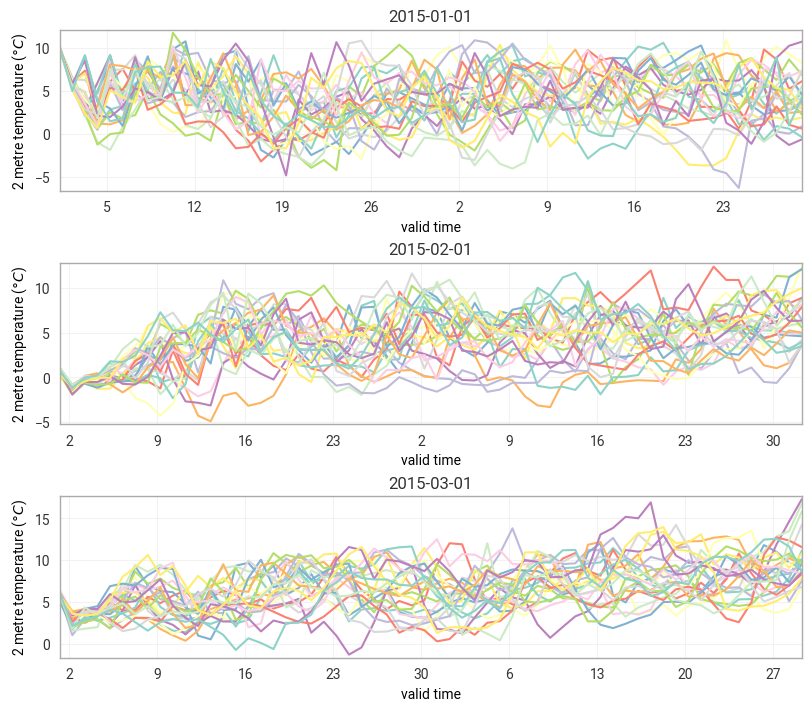

In [10]:
timeseries = ekp.timeseries.line(
    seas_daily_mean_by_step.t2m.sel(latitude=52, longitude=-1),
    x="valid_time",
    units="celsius",
    groupby="forecast_reference_time",
    colorby="member",
    label="{member}",
    columns=1,
    xticks={
        "frequency": "W"
    }
)
timeseries.subplot_titles("{forecast_reference_time:%Y-%m-%d}")
timeseries.show()

In [11]:
source = timeseries[0].layers[0].sources[0]

In [12]:
source.data

<xarray.DataArray 't2m' (step: 60)> Size: 480B
array([283.0443306 , 278.67019272, 276.32946777, 273.83097076,
       276.00404358, 276.42668915, 279.05548477, 278.41083527,
       280.35991287, 278.12334061, 283.46533203, 278.39687729,
       276.71641541, 280.79178238, 277.0393219 , 273.49428558,
       277.88068771, 282.29607773, 278.46079254, 275.63169098,
       276.47290039, 276.88494873, 272.74615479, 275.35797119,
       279.6015625 , 280.69644165, 280.20855713, 281.14611816,
       276.38564682, 274.72277832, 277.809021  , 280.32629395,
       279.02532959, 280.35754395, 282.3324585 , 280.15447998,
       281.60955811, 281.92181396, 280.84173584, 280.04852295,
       277.69670868, 276.74294662, 277.48355103, 278.44160461,
       279.7730484 , 281.62173843, 283.30784607, 282.94895172,
       283.7455864 , 281.27397537, 277.50253677, 277.12841797,
       275.74621964, 277.15820312, 277.73480225, 278.76092529,
       276.65563965, 275.53149414, 276.94421387, 277.74373372])
Coordinates:
  * step                     (step) timedelta64[ns] 480B 0 days 06:00:00 ... ...
    member                   <U2 8B '0'
    forecast_reference_time  datetime64[ns] 8B 2015-01-01
    latitude                 float64 8B 52.0
    longitude                float64 8B -1.0
    valid_time               (step) datetime64[ns] 480B 2015-01-01T06:00:00 ....
Attributes:
    standard_name:  unknown
    long_name:      2 metre temperature
    units:          kelvin
    level_type:     surface
    _earthkit:      {'message': b"GRIB\x00\x00t\x01\x00\x00<\x80b\x93\xff\x80...
    ek_grid_spec:   {"grid": [1.0, 1.0], "area": [70.0, -10.0, 40.0, 30.0]}